##Graphs for metals stacked##
based on scraped by-metal data in data/<metal_name>

Edited: 5/23


analysis by year
Edited: 5/29

added separate graphs for value and quantity to compare to other 2 stages
Edited: 6/5

#added a quantity v. price metric (as for the other 2 files too). 6/ 25

same as metalwise, fixced and matches online data 7/16

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict

# CONFIGURATION
base_dir = "../data"
country_code_file = "../ref/country_codes_V202501.csv"
years = [2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023]
# years = [2023]
refining_hs_codes = pd.read_csv("../ref/refining-hs-codes.csv")

In [2]:
refining_hs_codes

,Material,HS Code,Description
0,Copper,740311,"Refined copper, cathodes and sections of cathodes"
1,Copper,740819,Copper wire
2,Aluminum,760110,"Aluminum, unwrought, not alloyed"
3,Aluminum,760521,Aluminum wire
4,Tin,800110,"Tin, not alloyed, unwrought"
5,Nickel,750210,"Nickel, unwrought, not alloyed"
6,Tantalum,810330,"Tantalum, unwrought or powder"
7,Lithium,283691,Lithium carbonate
8,Cobalt,810520,"Cobalt, unwrought or powder"
9,Gold,710812,"Gold, unwrought, for non-monetary use"


In [4]:
# Load country codes
country_df = pd.read_csv(country_code_file)
country_lookup = dict(zip(country_df["country_code"], country_df["country_name"]))

# Metals to process (folders)
metal_dirs = [d for d in os.listdir(base_dir) if os.path.isdir(os.path.join(base_dir, d))]
hs_codes = []
# Color map
color_map = {
    # "zinc": "#a6761d"
    # "nickel": "#66a61e",
        # "copper": "#d95f02", 
    # "gold": "#e6ab02", "silver": "#7570b3", "lithium": "#1b9e77",
    # "nickel": "#66a61e", "cobalt": "#e7298a", "zinc": "#a6761d", "tin": "#666666",
    # "tungsten": "#1f78b4", "graphite": "#6a3d9a", "Rare Earths (REEs)": "#ff7f00",
    # "tantalum": "#8dd3c7", "indium": "#fb8072", "germanium": "#80b1d3", "gallium": "#fdb462", "lead": "#b3b3b3",
    # "lithium": "#1b9e77",
    # "aluminium": ["#a6761d", 0.01, 14.8], #skews data a lot
    "Rare Earths (REEs)": ["#ff7f00", .3, 632], #need to verify
    # "gold": ["#e6ab02", 0.1, 5100], #need to verify
    "tin": ["#666666", 0.5, 33.9],
    "tungsten": ["#1f78b4", 0.5, 68.5],
    "tantalum": ["#8dd3c7", 0.51, 262],
}

# Aggregate export data
export_value = defaultdict(lambda: defaultdict(float))
export_quantity = defaultdict(lambda: defaultdict(float))

for metal in metal_dirs:
    trade_path = os.path.join(base_dir, metal, "trade_data.csv")
    if not os.path.exists(trade_path):
        continue
    try:
        df = pd.read_csv(trade_path)
        df.rename(columns={"i": "exporter", "j": "importer", "k": "hs_code", "v": "value", "q": "quantity"}, inplace=True)
        df = df[df["year"].isin(years)]
        df = df[df["hs_code"].isin(refining_hs_codes["HS Code"])]
        grouped = df.groupby("exporter").agg({"value": "sum", "quantity": "sum"}).reset_index()
        for _, row in grouped.iterrows():
            export_value[int(row["exporter"])][metal] += row["value"]
            export_quantity[int(row["exporter"])][metal] += row["quantity"]
    except Exception as e:
        print(f"[ERROR] Failed to process {metal}: {e}")

# Build DataFrames
value_df = pd.DataFrame(export_value).T.fillna(0)
value_df = value_df.rename(columns={'earth-metals,_rare': 'Rare Earths (REEs)'})
quantity_df = pd.DataFrame(export_quantity).T.fillna(0)
quantity_df = quantity_df.rename(columns={'earth-metals,_rare': 'Rare Earths (REEs)'})

# Map exporter codes to country names
value_df.index = value_df.index.map(lambda x: country_lookup.get(x, f"Code {x}"))
quantity_df.index = quantity_df.index.map(lambda x: country_lookup.get(x, f"Code {x}"))


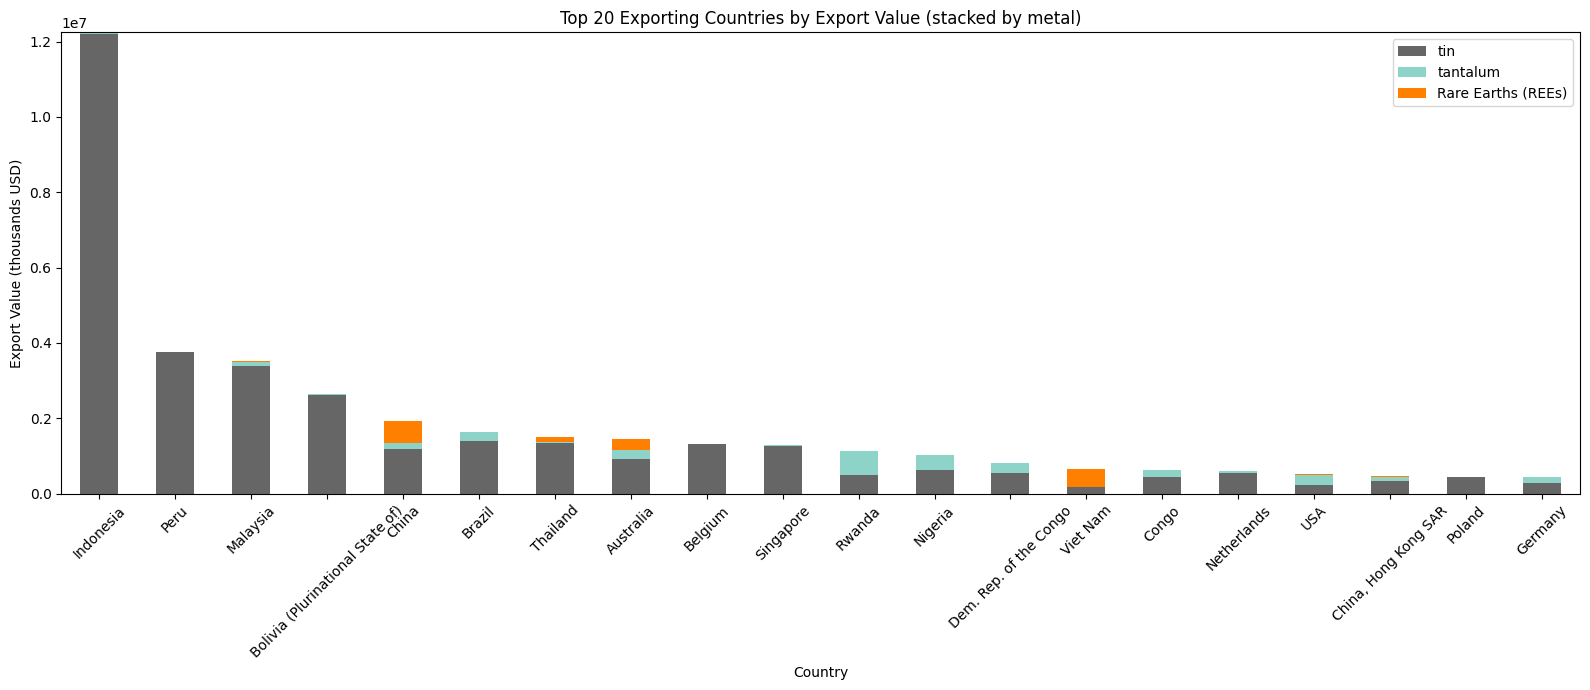

In [5]:
valid_metals = [col for col in value_df.columns if col in color_map]
value_df[valid_metals] = value_df[valid_metals].apply(pd.to_numeric, errors='coerce')
value_totals = value_df[valid_metals].sum(axis=1)

for metal in valid_metals:
    weight = color_map[metal][1]
    
    value_df[metal] *= weight

nonzero_totals = value_totals[value_totals > 0]

top_n = min(20, len(nonzero_totals))
top_exporters_value = nonzero_totals.nlargest(top_n).index

# 6. Filter value_df to these top exporters
value_df_top = value_df.loc[top_exporters_value].copy()
value_df_top["total"] = value_df_top[valid_metals].sum(axis=1)
value_df_top = value_df_top.sort_values(by="total", ascending=False).drop(columns="total")

# 7. Drop metals that have all NaNs for the selected top exporters
non_empty_metals = value_df_top[valid_metals].dropna(axis=1, how='all').columns.tolist()

# 8. Plot only if we have any non-empty metals to show
if not non_empty_metals:
    print("No numeric data available for selected metals and countries.")
else:
    colors = [color_map[m][0] for m in non_empty_metals]
    fig, ax = plt.subplots(figsize=(16, 7))
    value_df_top[non_empty_metals].plot(kind="bar", stacked=True, color=colors, ax=ax)
    ax.set_title(f"Top {top_n} Exporting Countries by Export Value (stacked by metal)")
    ax.set_ylabel("Export Value (thousands USD)")
    ax.set_xlabel("Country")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


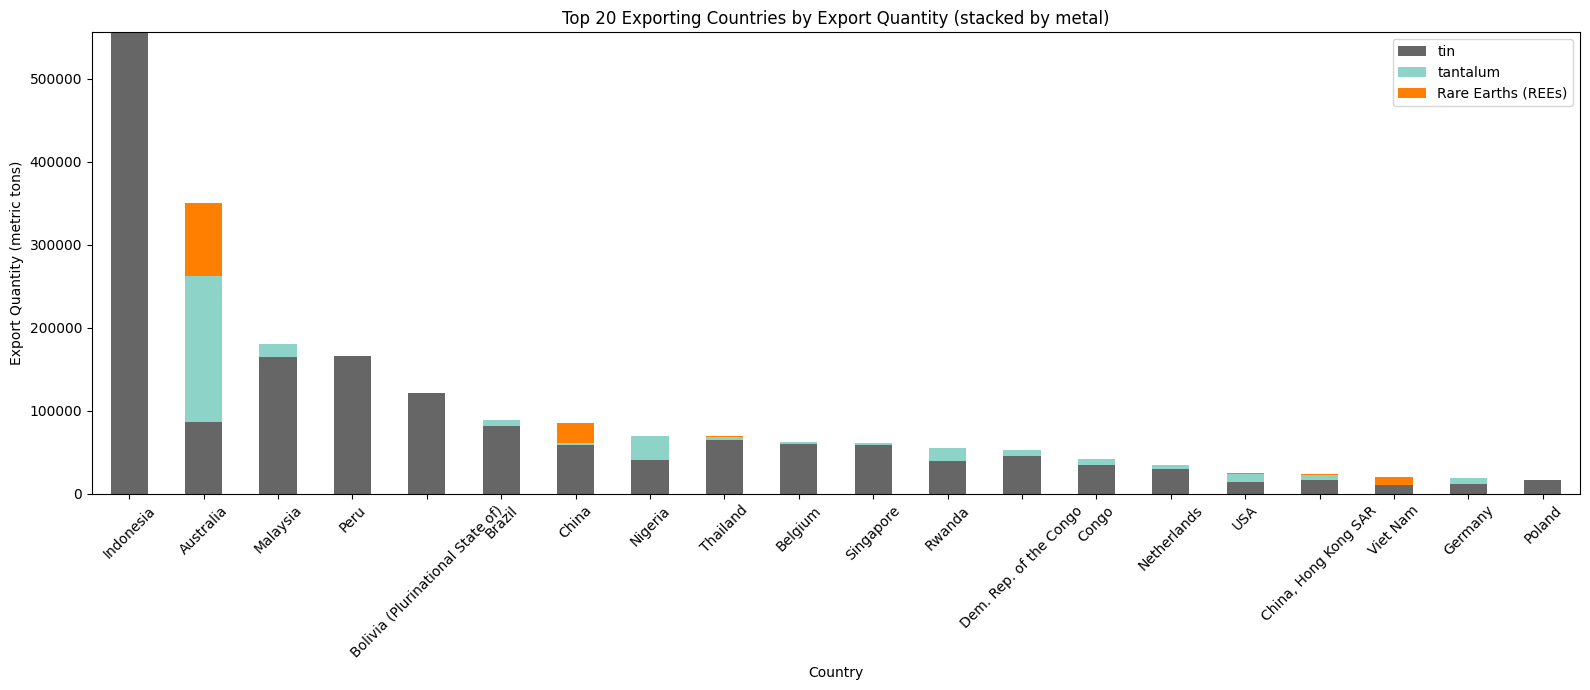

In [6]:
valid_metals = [col for col in quantity_df.columns if col in color_map]
quantity_df[valid_metals] = quantity_df[valid_metals].apply(pd.to_numeric, errors='coerce')
quantity_totals = quantity_df[valid_metals].sum(axis=1)

for metal in valid_metals:
    weight = color_map[metal][1]
    quantity_df[metal] *= weight

nonzero_totals = quantity_totals[value_totals > 0]

top_n = min(20, len(nonzero_totals))
top_exporters_quantity = nonzero_totals.nlargest(top_n).index

quantity_df_top = quantity_df.loc[top_exporters_value].copy()
quantity_df_top["total"] = quantity_df_top[valid_metals].sum(axis=1)
quantity_df_top = quantity_df_top.sort_values(by="total", ascending=False).drop(columns="total")

non_empty_metals = quantity_df_top[valid_metals].dropna(axis=1, how='all').columns.tolist()

if not non_empty_metals:
    print("No numeric data available for selected metals and countries.")
else:
    colors = [color_map[m][0] for m in non_empty_metals]
    fig, ax = plt.subplots(figsize=(16, 7))
    quantity_df_top[non_empty_metals].plot(kind="bar", stacked=True, color=colors, ax=ax)
    ax.set_title(f"Top {top_n} Exporting Countries by Export Quantity (stacked by metal)")
    ax.set_ylabel("Export Quantity (metric tons)")
    ax.set_xlabel("Country")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


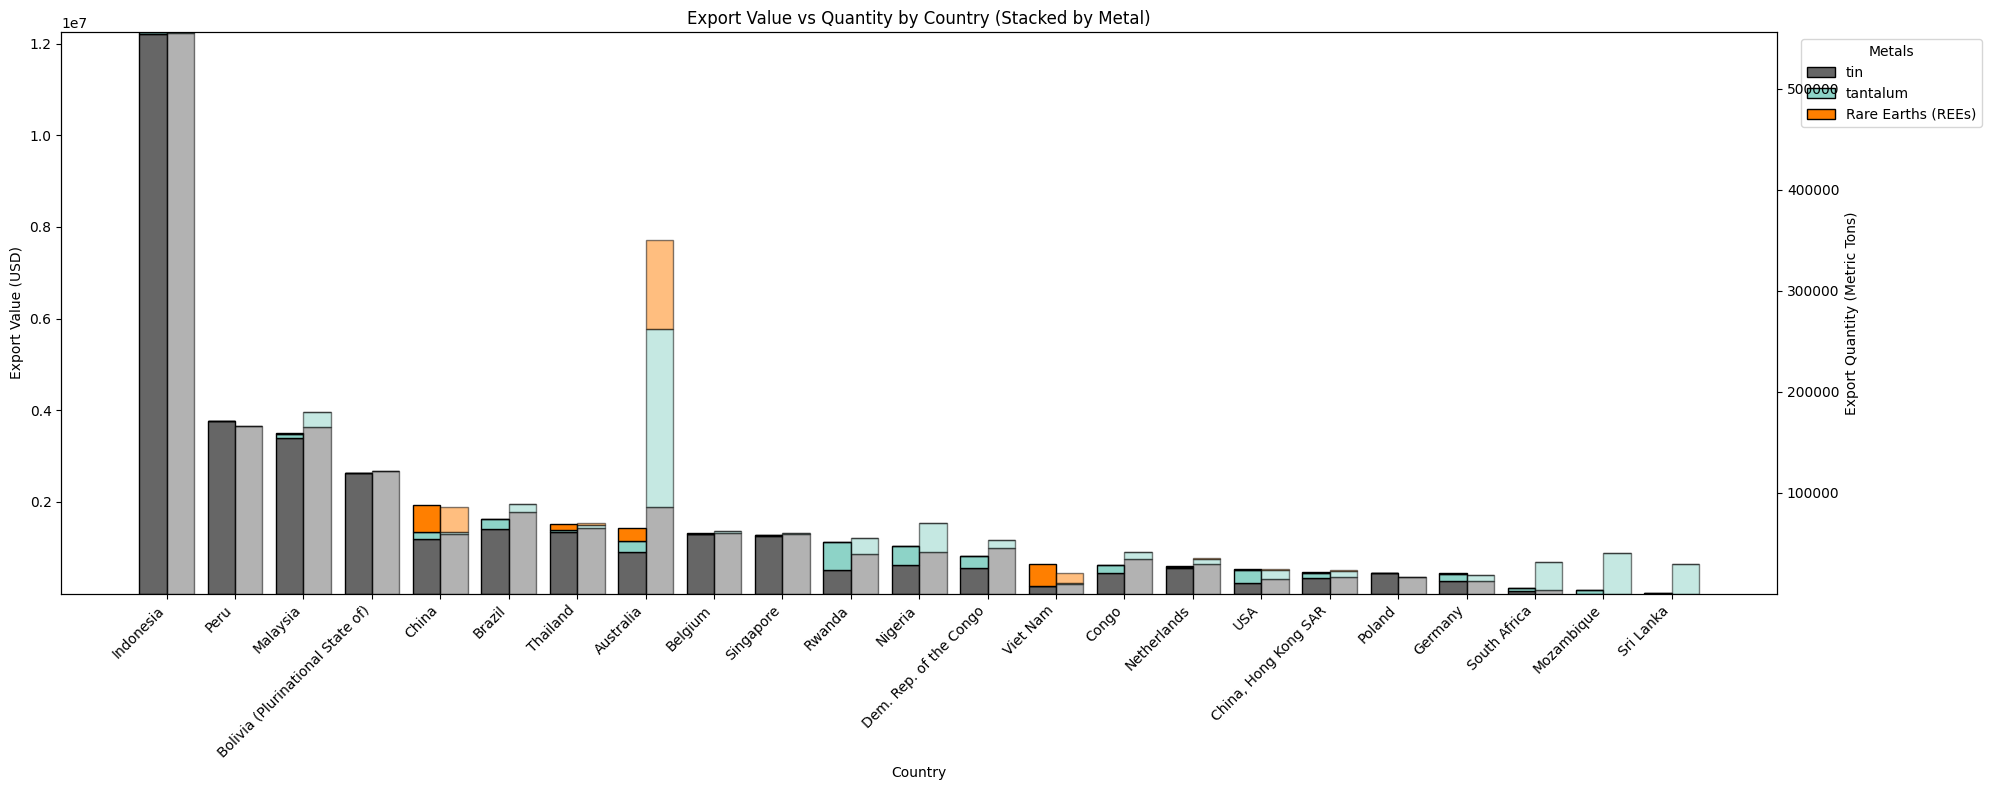

In [7]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# === Union of top countries ===
combined_exporters = sorted(set(top_exporters_value).union(set(top_exporters_quantity)))

# Filter and align value & quantity DFs
valid_metals = [col for col in value_df.columns if col in color_map]

value_df_filtered = value_df[valid_metals].reindex(combined_exporters).fillna(0)
quantity_df_filtered = quantity_df[valid_metals].reindex(combined_exporters).fillna(0)

# Order countries by total export value
value_totals = value_df_filtered.sum(axis=1)
ordered_exporters = value_totals.sort_values(ascending=False).index
value_df_filtered = value_df_filtered.loc[ordered_exporters]
quantity_df_filtered = quantity_df_filtered.loc[ordered_exporters]

# Set up plot
x = np.arange(len(ordered_exporters))
bar_width = 0.4

fig, ax_val = plt.subplots(figsize=(20, 8))
ax_qty = ax_val.twinx()

# === Stack value bars (darker) ===
bottom_val = np.zeros(len(ordered_exporters))
shown_labels = set()

for metal in valid_metals:
    label = metal if metal not in shown_labels else None
    ax_val.bar(x - bar_width/2, value_df_filtered[metal], width=bar_width,
               bottom=bottom_val, label=label,
               color=color_map[metal][0], edgecolor='black')
    bottom_val += value_df_filtered[metal]
    shown_labels.add(metal)

# === Stack quantity bars (lighter) ===
bottom_qty = np.zeros(len(ordered_exporters))
for metal in valid_metals:
    ax_qty.bar(x + bar_width/2, quantity_df_filtered[metal], width=bar_width,
               bottom=bottom_qty, color=color_map[metal][0], edgecolor='black', alpha=0.5)
    bottom_qty += quantity_df_filtered[metal]

# === Axis styling ===
ax_val.set_xticks(x)
ax_val.set_xticklabels(ordered_exporters, rotation=45, ha='right')
ax_val.set_title("Export Value vs Quantity by Country (Stacked by Metal)")
ax_val.set_xlabel("Country")
ax_val.set_ylabel("Export Value (USD)", color='black')
ax_qty.set_ylabel("Export Quantity (Metric Tons)", color='black')

# ax_val.set_yscale('log')
# ax_qty.set_yscale('log')

ax_val.legend(title="Metals", bbox_to_anchor=(1.01, 1), loc="upper left")

plt.tight_layout()
plt.show()


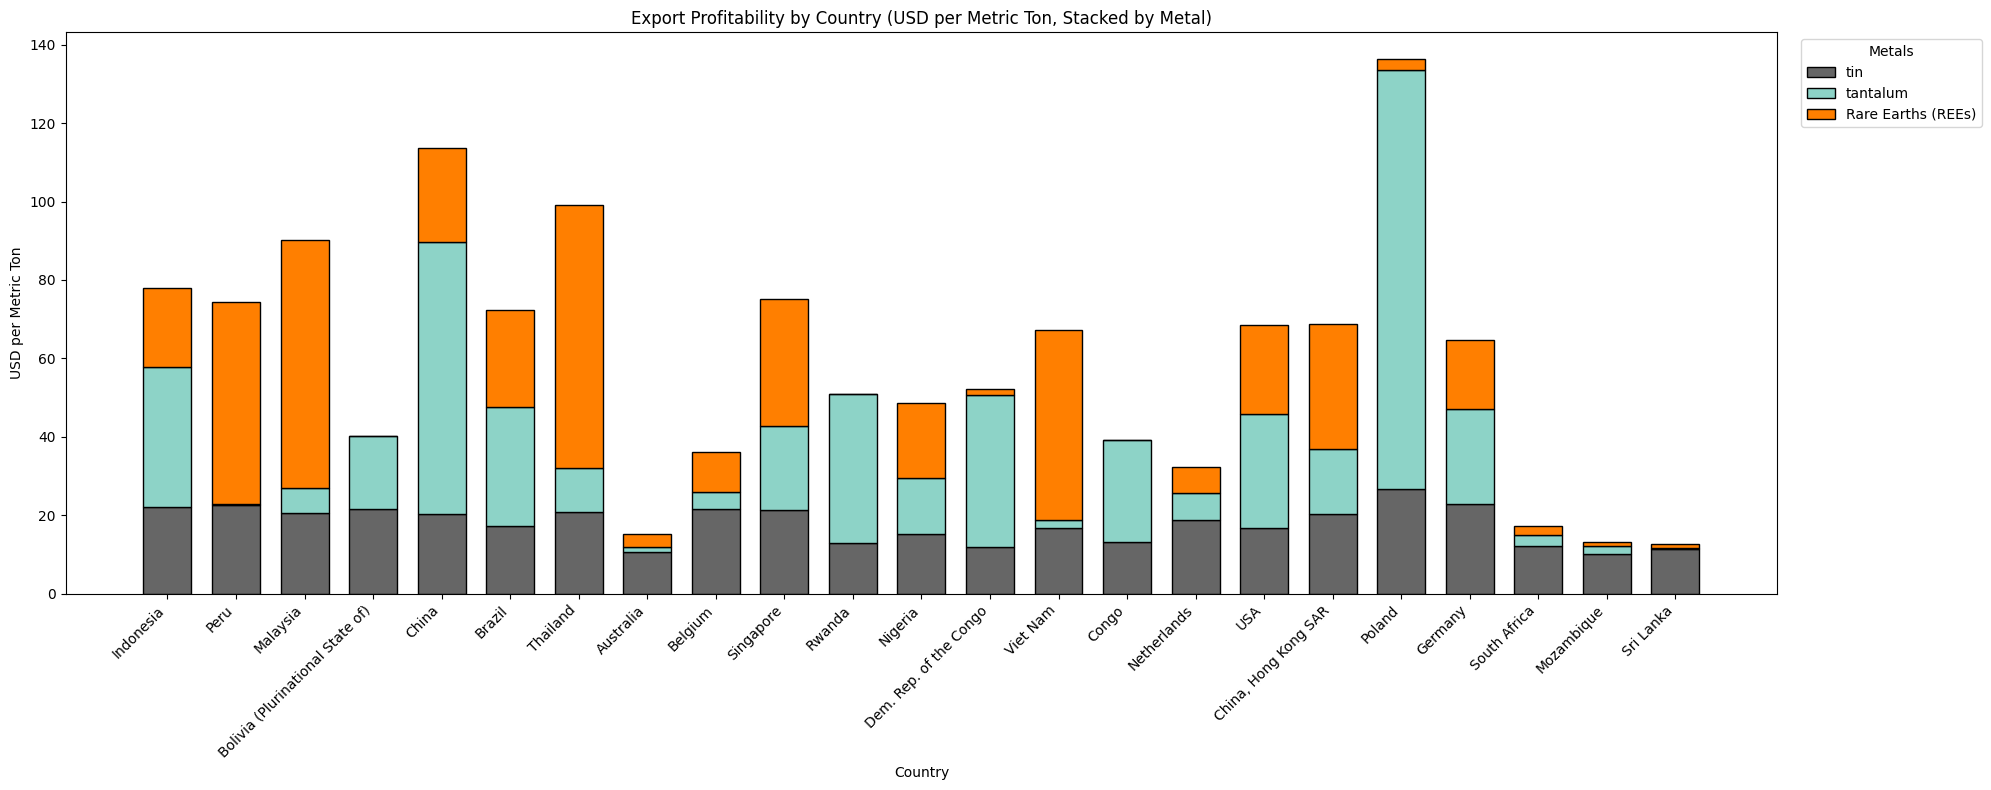

In [8]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# === Use existing filtered data ===
valid_metals = [col for col in value_df.columns if col in color_map]

value_df_filtered = value_df[valid_metals].reindex(ordered_exporters).fillna(0)
quantity_df_filtered = quantity_df[valid_metals].reindex(ordered_exporters).fillna(0)

# Avoid divide-by-zero
quantity_df_filtered = quantity_df_filtered.replace(0, np.nan)

# === Compute profitability ===
profitability_df = value_df_filtered / quantity_df_filtered
profitability_df = profitability_df.fillna(0)

# === Plot stacked bar chart ===
x = np.arange(len(ordered_exporters))
bar_width = 0.7

fig, ax = plt.subplots(figsize=(20, 8))
bottom_profit = np.zeros(len(ordered_exporters))
shown_labels = set()

for metal in valid_metals:
    label = metal if metal not in shown_labels else None
    ax.bar(x, profitability_df[metal], width=bar_width,
           bottom=bottom_profit, label=label,
           color=color_map[metal][0], edgecolor='black')
    bottom_profit += profitability_df[metal]
    shown_labels.add(metal)

# === Axis styling ===
ax.set_xticks(x)
ax.set_xticklabels(ordered_exporters, rotation=45, ha='right')
ax.set_title("Export Profitability by Country (USD per Metric Ton, Stacked by Metal)")
ax.set_ylabel("USD per Metric Ton")
ax.set_xlabel("Country")
ax.legend(title="Metals", bbox_to_anchor=(1.01, 1), loc="upper left")

plt.tight_layout()
plt.show()


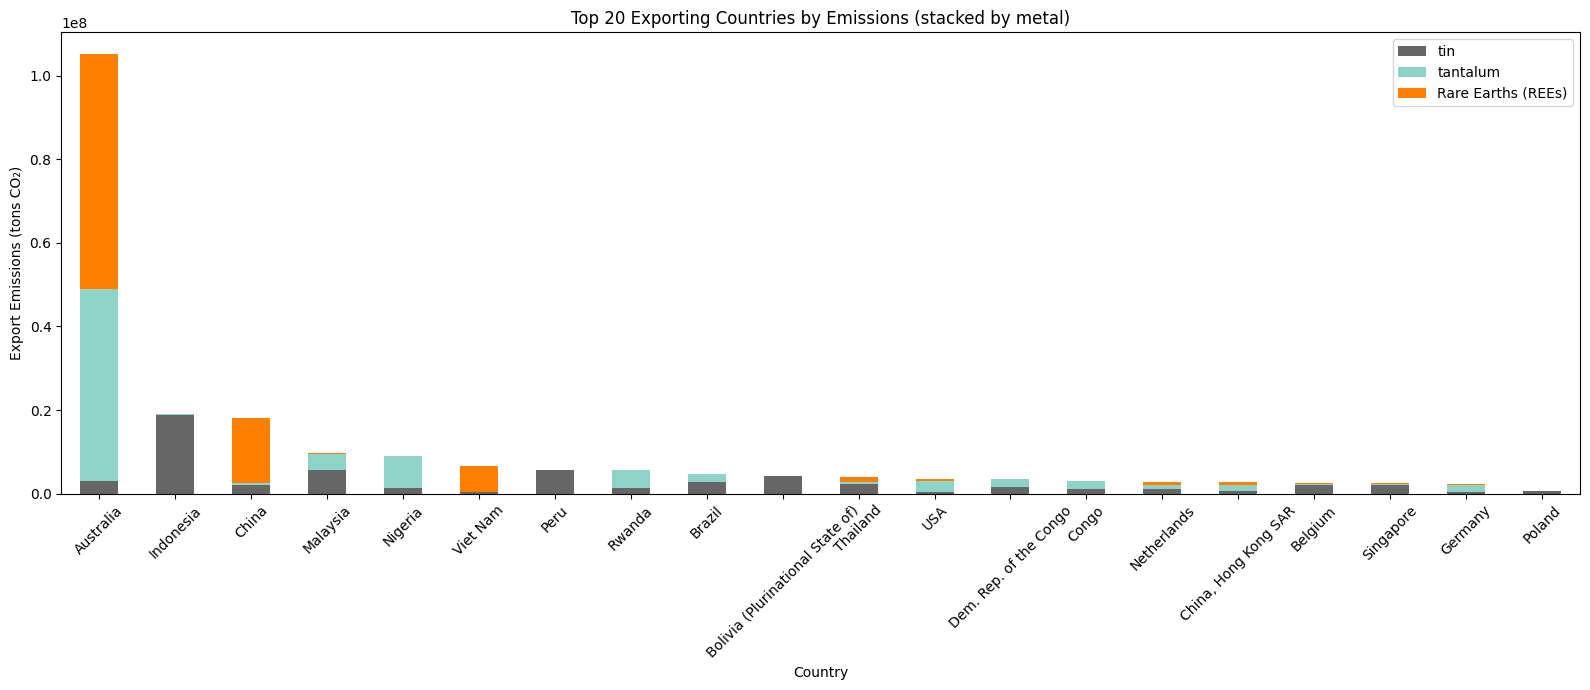

In [9]:
valid_metals = [col for col in quantity_df.columns if col in color_map]
quantity_df[valid_metals] = quantity_df[valid_metals].apply(pd.to_numeric, errors='coerce')

# Apply emissions factors to get emissions per country per metal
emissions_df = pd.DataFrame(index=quantity_df.index)

for metal in valid_metals:
    emissions_factor = color_map[metal][2]
    emissions_df[metal] = quantity_df[metal] * emissions_factor

# Sum total emissions per country
total_emissions = emissions_df.sum(axis=1)

# Filter based on value exporters to stay consistent with top_exporters_value
nonzero_emissions = total_emissions.loc[top_exporters_value]

# Select top N by total emissions
top_n = min(20, len(nonzero_emissions))
top_exporters_emissions = nonzero_emissions.nlargest(top_n).index

# Subset and prepare emissions data
emissions_top = emissions_df.loc[top_exporters_emissions].copy()
emissions_top["total"] = emissions_top[valid_metals].sum(axis=1)
emissions_top = emissions_top.sort_values(by="total", ascending=False).drop(columns="total")

# Drop metals with all NaNs
non_empty_metals = emissions_top[valid_metals].dropna(axis=1, how='all').columns.tolist()

# Plot
if not non_empty_metals:
    print("No numeric data available for selected metals and countries.")
else:
    colors = [color_map[m][0] for m in non_empty_metals]
    fig, ax = plt.subplots(figsize=(16, 7))
    emissions_top[non_empty_metals].plot(kind="bar", stacked=True, color=colors, ax=ax)
    ax.set_title(f"Top {top_n} Exporting Countries by Emissions (stacked by metal)")
    ax.set_ylabel("Export Emissions (tons CO₂)")
    ax.set_xlabel("Country")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


In [24]:
value_df_filtered

,lithium
Chile,2.046111e+07
Argentina,3.039552e+06
China,1.698358e+06
Belgium,5.643808e+05
Germany,3.590012e+05
Rep. of Korea,2.379843e+05
United Kingdom,2.364384e+05
Netherlands,2.217541e+05
USA,2.006736e+05
France,9.197563e+04


In [25]:
quantity_df_filtered

,lithium
Chile,1106465.685
Argentina,277491.568
China,66716.047
Belgium,43592.472
Germany,27440.143
Rep. of Korea,13075.922
United Kingdom,10249.857
Netherlands,23297.492
USA,13110.573
France,9389.237


In [26]:
profitability_df

,lithium
Chile,18.492311
Argentina,10.953675
China,25.456513
Belgium,12.946748
Germany,13.083067
Rep. of Korea,18.200190
United Kingdom,23.067481
Netherlands,9.518367
USA,15.306241
France,9.795858


In [130]:
#  GLOBAL SHARE OF EXPORT VALUE (MANUFACTURING) 
valid_categories = [col for col in value_df_top.columns if col in color_map]

global_total_value = value_df[valid_categories].sum().sum()
share_value = value_df[valid_categories].sum(axis=1) / global_total_value * 100
share_value_top = share_value[top_exporters[:15]]  # Top 15 exporters

fig, ax = plt.subplots(figsize=(10, 10))
ax.pie(
    share_value_top,
    labels=share_value_top.index,
    autopct="%1.1f%%",
    startangle=90,
    counterclock=False,
)
ax.set_title("Global Share of Export Value – Top 15 Countries (Top Mining Categories)")
plt.tight_layout()
plt.show()


NameError: name 'top_exporters' is not defined

In [131]:
#metal concentration 
concentration_ratio = value_df[valid_metals].div(value_df[valid_metals].sum(axis=1), axis=0)
max_share_per_country = concentration_ratio.max(axis=1)
top_metal_per_country = concentration_ratio.idxmax(axis=1)

#coordinate colors
bar_colors = top_metal_per_country[top_exporters].map(color_map)

#plot
fig, ax = plt.subplots(figsize=(14, 6))
max_share_per_country[top_exporters].plot(
    kind='bar',
    ax=ax,
    color=bar_colors,
    edgecolor='black'
)

# Legend setup
handles = [plt.Rectangle((0, 0), 1, 1, color=color_map[m]) for m in sorted(set(top_metal_per_country[top_exporters]))]
labels = sorted(set(top_metal_per_country[top_exporters]))

ax.set_title("Export Specialization Ratio (Color = Top Exported Metal)")
ax.set_ylabel("Share of Top Export Metal")
ax.set_xlabel("Country")
plt.axhline(0.5, color="black", linestyle="--", linewidth=0.8)
plt.xticks(rotation=45)
ax.legend(handles, labels, title="Dominant Metal")
plt.tight_layout()
plt.show()


/var/folders/13/n1l89mln5nvdj5127ntt9yj40000gs/T/ipykernel_77828/3163960660.py:4: FutureWarning: The behavior of DataFrame.idxmax with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  top_metal_per_country = concentration_ratio.idxmax(axis=1)


NameError: name 'top_exporters' is not defined

In [132]:
#export value and quantity side-by-side
total_val = value_df[valid_metals].sum(axis=1)
total_qty = quantity_df[valid_metals].sum(axis=1)

comparison_df = pd.DataFrame({
    "Total Value (USD thousands)": total_val[top_exporters],
    "Total Quantity (metric tons)": total_qty[top_exporters]
})

fig, ax = plt.subplots(figsize=(14, 6))
comparison_df.plot(kind="bar", ax=ax)
ax.set_title("Total Export Value vs Quantity by Country")
ax.set_ylabel("Total Value / Quantity")
ax.set_xlabel("Country")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


NameError: name 'top_exporters' is not defined

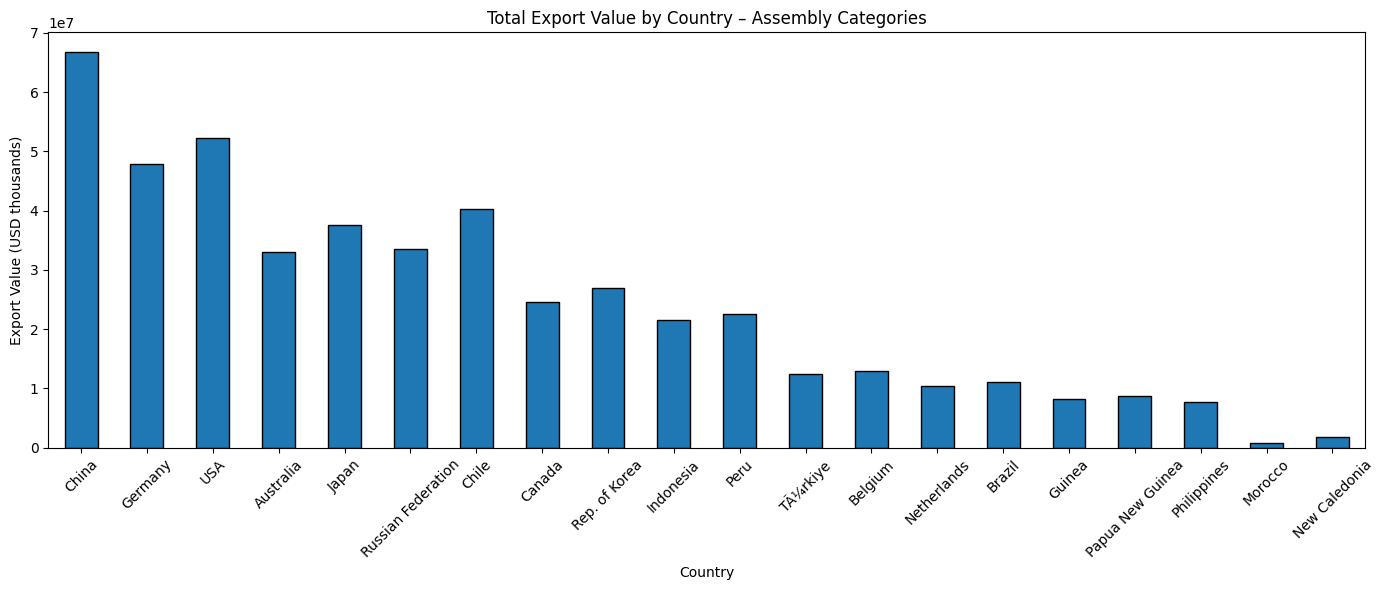

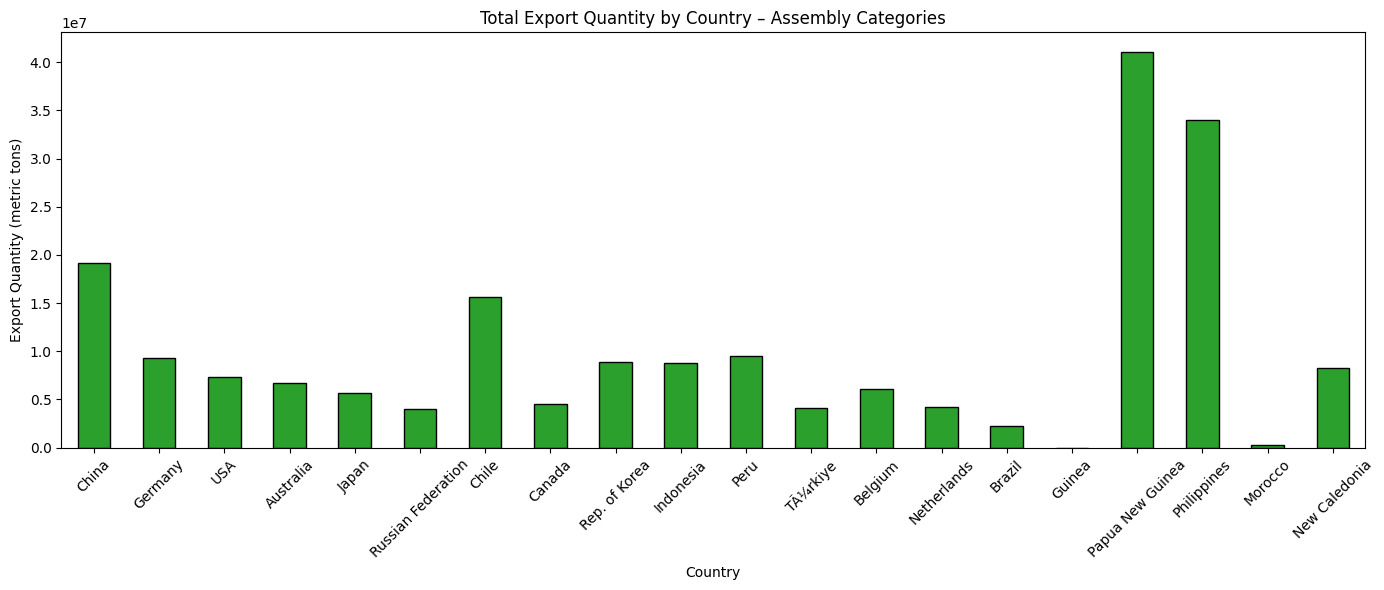

In [6]:
#  EXPORT VALUE VS QUANTITY: Assembly 

# Compute totals for selected categories
total_val = value_df[valid_categories].sum(axis=1)
total_qty = quantity_df[valid_categories].sum(axis=1)

# Select only top exporters
total_val_top = total_val[top_exporters]
total_qty_top = total_qty[top_exporters]

#  PLOT: Total Export Value 
fig, ax1 = plt.subplots(figsize=(14, 6))
total_val_top.plot(kind="bar", ax=ax1, color="#1f77b4", edgecolor="black")
ax1.set_title("Total Export Value by Country – Assembly Categories")
ax1.set_ylabel("Export Value (USD thousands)")
ax1.set_xlabel("Country")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#  PLOT: Total Export Quantity 
fig, ax2 = plt.subplots(figsize=(14, 6))
total_qty_top.plot(kind="bar", ax=ax2, color="#2ca02c", edgecolor="black")
ax2.set_title("Total Export Quantity by Country – Assembly Categories")
ax2.set_ylabel("Export Quantity (metric tons)")
ax2.set_xlabel("Country")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


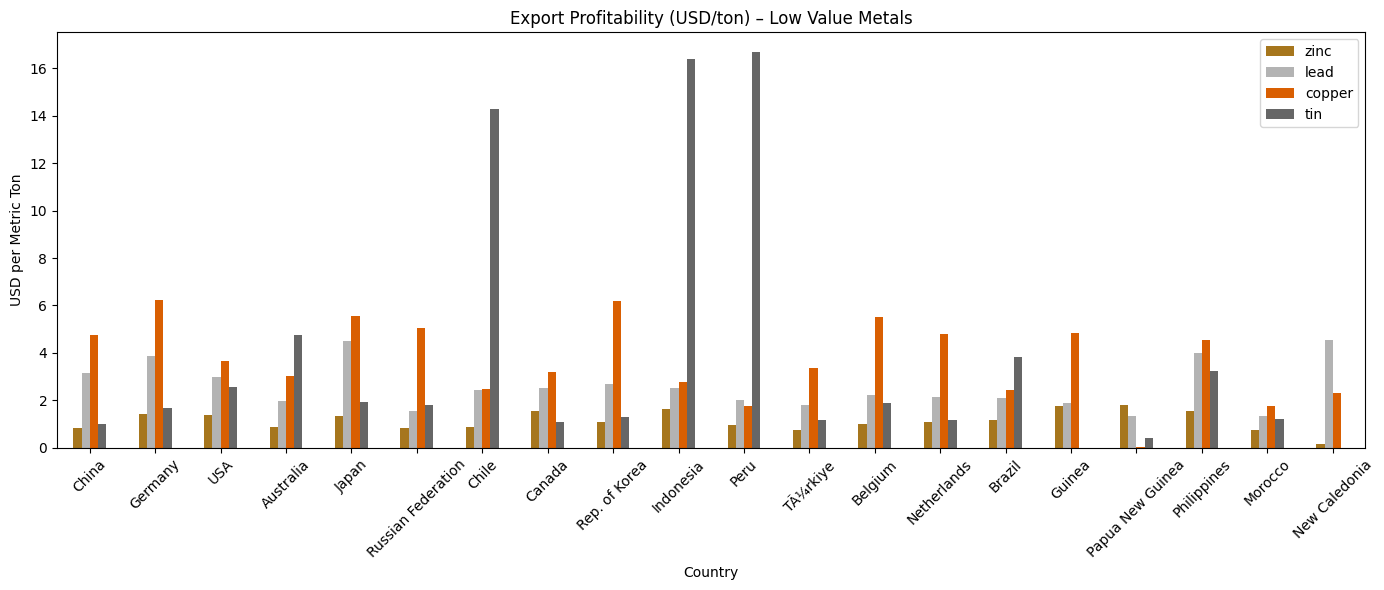

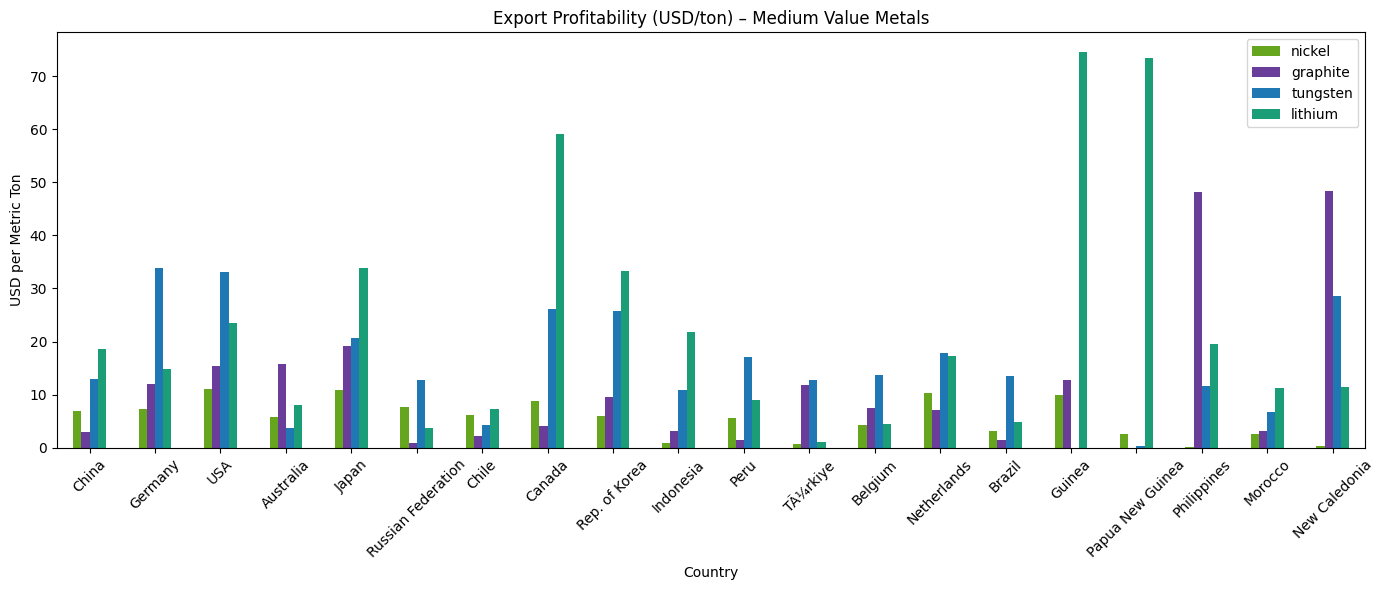

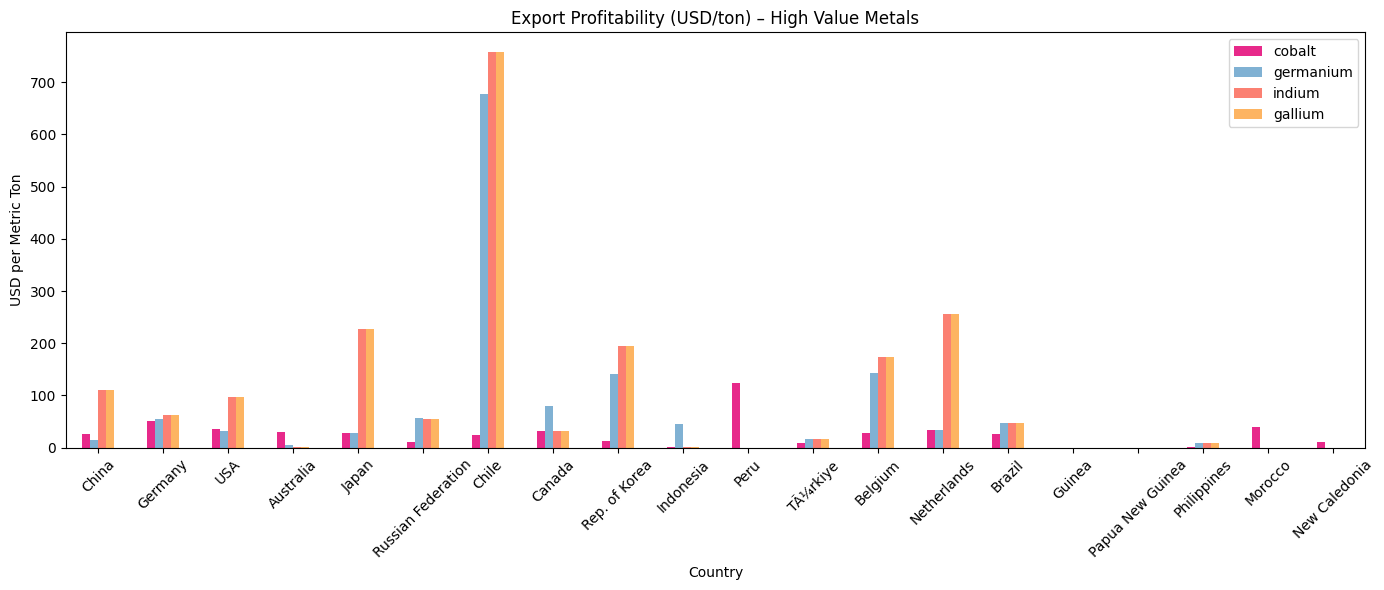

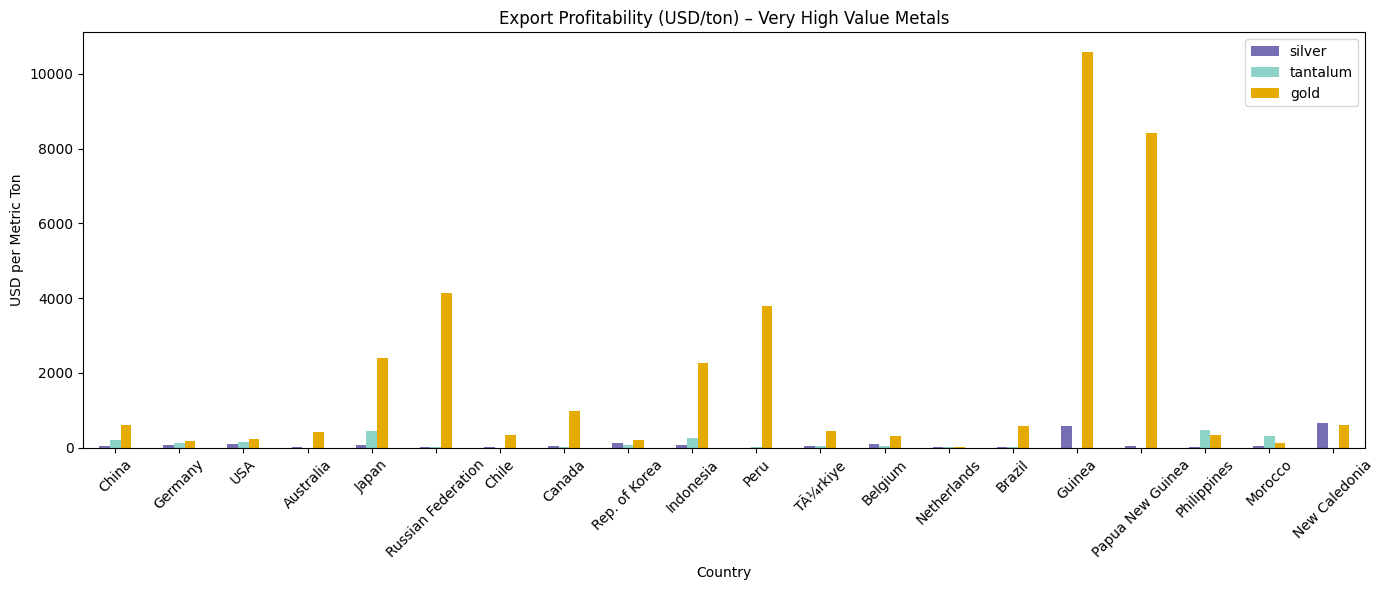

In [7]:
#  USD PER TON (STRATIFIED BY PRICE RANGE) FOR MINING 

# Step 1: Clean and compute USD per ton
quantity_df_clean = quantity_df.replace(0, float("nan"))
value_per_ton_df = value_df / quantity_df_clean
value_per_ton_df = value_per_ton_df[valid_metals]

# Step 2: Clip outliers at 95th percentile for each metal
clipped_df = value_per_ton_df.copy()
for col in clipped_df.columns:
    clip_val = clipped_df[col].quantile(0.95)
    clipped_df[col] = clipped_df[col].clip(upper=clip_val)

clipped_df = clipped_df.fillna(0)

# Step 3: Compute mean USD/ton per metal across countries and group them
metal_means = clipped_df.mean().sort_values()
price_bins = pd.qcut(metal_means, 4, labels=["Low", "Medium", "High", "Very High"])
grouped_metals = {label: metal_means[price_bins == label].index.tolist() for label in price_bins.unique()}

# Step 4: Plot separate graphs for each group
for label, group_cols in grouped_metals.items():
    if not group_cols:
        continue
    fig, ax = plt.subplots(figsize=(14, 6))
    clipped_df.loc[top_exporters, group_cols].plot(kind="bar", ax=ax, color=[color_map[c] for c in group_cols])
    ax.set_title(f"Export Profitability (USD/ton) – {label} Value Metals")
    ax.set_ylabel("USD per Metric Ton")
    ax.set_xlabel("Country")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


In [10]:
value_df.to_csv("refining_export_value.csv")
quantity_df.to_csv("refining_export_quantity.csv")